# Model evaluation with ATR based label construction including all features

In [10]:
import pandas as pd
import pandas_ta as ta
import numpy as np

## Loading the Data

In [11]:
df = pd.read_csv('/Users/tobiassteinbach/code/rajeevankrajendran-creator/systematic_trading/systematic_trading_backend/notebooks/btc_1hour_cleaned.csv')

In [12]:
df.head(2)

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2018-01-01 00:00:00,13715.65,13715.65,13400.01,13529.01,443.356199,2018-01-01 00:59:59.999,5.993910e+06,5228,228.521921,3.090541e+06,0
1,2018-01-01 01:00:00,13528.99,13595.89,13155.38,13203.06,383.697006,2018-01-01 01:59:59.999,5.154522e+06,4534,180.840403,2.430449e+06,0


## Setting the correct formats and cleaning Dataframe

In [13]:
df['Open time'] = pd.to_datetime(df['Open time'])
df['Close time'] = pd.to_datetime(df['Close time'])

In [14]:
df = df.set_index('Open time')

In [15]:
df.head(3)

,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
Open time,,,,,,,,,,,
2018-01-01 00:00:00,13715.65,13715.65,13400.01,13529.01,443.356199,2018-01-01 00:59:59.999,5.993910e+06,5228,228.521921,3.090541e+06,0
2018-01-01 01:00:00,13528.99,13595.89,13155.38,13203.06,383.697006,2018-01-01 01:59:59.999,5.154522e+06,4534,180.840403,2.430449e+06,0
2018-01-01 02:00:00,13203.00,13418.43,13200.00,13330.18,429.064572,2018-01-01 02:59:59.999,5.710192e+06,4887,192.237935,2.558505e+06,0


In [16]:
df.shape

(71588, 11)

# Feature Engineering

In [17]:
# ROC — Rate of Change
def compute_roc(df):
    df['roc_10'] = df['Close'].pct_change(periods=10)
    df['roc_21'] = df['Close'].pct_change(periods=21)
    return df

# MACD Histogram
def compute_macd(df):
    macd = ta.macd(df['Close'], fast=12, slow=26, signal=9)
    df['macd_histogram'] = macd['MACDh_12_26_9']
    return df

# ADX — used as feature AND for regime detection (execution layer)
def compute_adx(df):
    df['adx'] = ta.adx(df['High'], df['Low'], df['Close'], length=14)['ADX_14']
    return df

# RSI 14
def compute_rsi(df):
    df['rsi_14'] = ta.rsi(df['Close'], length=14)
    return df

# RSI Divergence (binary: 1=bullish, -1=bearish, 0=none)
def compute_rsi_div(df):
    df['price_high'] = df['Close'].rolling(14).max()
    df['price_low']  = df['Close'].rolling(14).min()
    df['rsi_high']   = df['rsi_14'].rolling(14).max()
    df['rsi_low']    = df['rsi_14'].rolling(14).min()
    bearish_div = (df['Close'] == df['price_high']) & (df['rsi_14'] < df['rsi_high'])
    bullish_div = (df['Close'] == df['price_low'])  & (df['rsi_14'] > df['rsi_low'])
    df['rsi_divergence'] = 0
    df.loc[bullish_div, 'rsi_divergence'] = 1
    df.loc[bearish_div, 'rsi_divergence'] = -1
    df.drop(columns=['price_high', 'price_low', 'rsi_high', 'rsi_low'], inplace=True)
    return df

# OBV Change (10 bars)
def compute_obv(df):
    direction = df['Close'].diff(1).apply(
        lambda x: 1 if x > 0 else (-1 if x < 0 else 0)
    )
    obv = (df['Volume'] * direction).cumsum()
    df['obv_change'] = obv.diff(10)
    return df

# Volume ROC (10 bars)
def compute_vol_roc(df):
    df['volume_roc'] = df['Volume'].pct_change(periods=10)
    return df

# Bollinger Band Width
def compute_bollinger(df):
    window, num_std = 20, 2
    df['sma_20']     = df['Close'].rolling(window=window).mean()
    df['sigma']      = df['Close'].rolling(window=window).std()
    df['upper_band'] = df['sma_20'] + num_std * df['sigma']
    df['lower_band'] = df['sma_20'] - num_std * df['sigma']
    df['bb_width']   = (df['upper_band'] - df['lower_band']) / df['sma_20']
    df.drop(columns=['upper_band', 'lower_band', 'sma_20', 'sigma'], inplace=True)
    return df

# Cyclical time features
def compute_time_features(df):
    df['hour_sin']  = np.sin(2 * np.pi * df.index.hour / 24)
    df['hour_cos']  = np.cos(2 * np.pi * df.index.hour / 24)
    df['dow_sin']   = np.sin(2 * np.pi * df.index.dayofweek / 7)
    df['dow_cos']   = np.cos(2 * np.pi * df.index.dayofweek / 7)
    df['month_sin'] = np.sin(2 * np.pi * df.index.month / 12)
    df['month_cos'] = np.cos(2 * np.pi * df.index.month / 12)
    return df

# SMA 50 and SMA 200 — regime detection only, NOT in feature matrix X
def compute_regime(df):
    df['sma_50']  = df['Close'].rolling(50).mean()
    df['sma_200'] = df['Close'].rolling(200).mean()
    df['regime']  = (
        (df['sma_50']  > df['sma_200']) &
        (df['Close']   > df['sma_50'])  &
        (df['Close']   > df['sma_200'])
    ).astype(int)
    return df

# ATR 14 — required for label construction in MVP v2
def compute_atr(df):
    df['atr_14'] = ta.atr(df['High'], df['Low'], df['Close'], length=14)
    return df

# NATR — Normalised ATR
def compute_natr(df):
    df['natr'] = ta.natr(df['High'], df['Low'], df['Close'], length=14)
    return df

## Pipeline

In [18]:
def feature_pipeline(df):
    steps = [
        compute_roc,
        compute_macd,
        compute_adx,
        compute_atr,
        compute_natr,
        compute_rsi,
        compute_rsi_div,
        compute_obv,
        compute_vol_roc,
        compute_bollinger,
        compute_time_features,
        compute_regime,    # execution layer only — does NOT go into X
    ]
    for step in steps:
        df = step(df)
    return df

df = feature_pipeline(df)

print(f"Shape after feature engineering: {df.shape}")
df.head(2)

Shape after feature engineering: (71588, 31)


,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,...,bb_width,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,sma_50,sma_200,regime
Open time,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,13715.65,13715.65,13400.01,13529.01,443.356199,2018-01-01 00:59:59.999,5.993910e+06,5228,228.521921,3.090541e+06,...,NaN,0.000000,1.000000,0.0,1.0,0.5,0.866025,NaN,NaN,0
2018-01-01 01:00:00,13528.99,13595.89,13155.38,13203.06,383.697006,2018-01-01 01:59:59.999,5.154522e+06,4534,180.840403,2.430449e+06,...,NaN,0.258819,0.965926,0.0,1.0,0.5,0.866025,NaN,NaN,0


# Creating y

In [19]:
# Lookahead window - change this value to test different horizons
N = 5

# Step 1 - Forward return
df['forward_return'] = df['Close'].pct_change(periods=N).shift(-N)

In [20]:
# Step 2 - Binary Label
m_values = [0.5, 1, 1.5, 2]

for m in m_values:
    df[f'label_{m}'] = (df['forward_return'] > (m * df['atr_14'] / df['Close'])).astype(int)
    count_ones = df[f'label_{m}'].sum()
    percentage = (count_ones / len(df)) * 100
    print(f"Label with m={m}: {count_ones} BUY signals ({percentage:.2f}%)")
    # 1 - BUY, 0 - SELL

df['label'] = df['label_0.5']

Label with m=0.5: 23050 BUY signals (32.20%)
Label with m=1: 13573 BUY signals (18.96%)
Label with m=1.5: 8160 BUY signals (11.40%)
Label with m=2: 5279 BUY signals (7.37%)


In [21]:
df.shape

(71588, 37)

In [22]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Close time',
       'Quote asset volume', 'Number of trades', 'Taker buy base asset volume',
       'Taker buy quote asset volume', 'Ignore', 'roc_10', 'roc_21',
       'macd_histogram', 'adx', 'atr_14', 'natr', 'rsi_14', 'rsi_divergence',
       'obv_change', 'volume_roc', 'bb_width', 'hour_sin', 'hour_cos',
       'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'sma_50', 'sma_200',
       'regime', 'forward_return', 'label_0.5', 'label_1', 'label_1.5',
       'label_2', 'label'],
      dtype='str')

## Creating the lags

In [23]:
# Number of lags to create
N_lags = 5

feature_cols = ['Volume','roc_10', 'roc_21', 'macd_histogram', 'adx']

# Create lags for all feature columns
for col in feature_cols:
    for lag in range(1, N_lags + 1):
        df[f'{col}_lag{lag}'] = df[col].shift(lag)

# Drop NaN rows created by the lags
df = df.dropna(subset=feature_cols + [f'{col}_lag{i}' for col in feature_cols for i in range(1, N_lags + 1)] + ['label'])

In [24]:
df.shape

(71550, 62)

In [25]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Close time',
       'Quote asset volume', 'Number of trades', 'Taker buy base asset volume',
       'Taker buy quote asset volume', 'Ignore', 'roc_10', 'roc_21',
       'macd_histogram', 'adx', 'atr_14', 'natr', 'rsi_14', 'rsi_divergence',
       'obv_change', 'volume_roc', 'bb_width', 'hour_sin', 'hour_cos',
       'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'sma_50', 'sma_200',
       'regime', 'forward_return', 'label_0.5', 'label_1', 'label_1.5',
       'label_2', 'label', 'Volume_lag1', 'Volume_lag2', 'Volume_lag3',
       'Volume_lag4', 'Volume_lag5', 'roc_10_lag1', 'roc_10_lag2',
       'roc_10_lag3', 'roc_10_lag4', 'roc_10_lag5', 'roc_21_lag1',
       'roc_21_lag2', 'roc_21_lag3', 'roc_21_lag4', 'roc_21_lag5',
       'macd_histogram_lag1', 'macd_histogram_lag2', 'macd_histogram_lag3',
       'macd_histogram_lag4', 'macd_histogram_lag5', 'adx_lag1', 'adx_lag2',
       'adx_lag3', 'adx_lag4', 'adx_lag5'],
      dtype='str')

## Creating the Feature Matrix and y

In [26]:
X = df[['Volume','roc_10', 'roc_21', 'macd_histogram', 'adx',
                     'Volume_lag1', 'Volume_lag2', 'Volume_lag3', 'Volume_lag4', 'Volume_lag5',
                     'roc_10_lag1', 'roc_10_lag2', 'roc_10_lag3', 'roc_10_lag4', 'roc_10_lag5',
                     'roc_21_lag1', 'roc_21_lag2', 'roc_21_lag3', 'roc_21_lag4', 'roc_21_lag5',
                     'macd_histogram_lag1', 'macd_histogram_lag2', 'macd_histogram_lag3', 'macd_histogram_lag4', 'macd_histogram_lag5',
                     'adx_lag1', 'adx_lag2', 'adx_lag3', 'adx_lag4', 'adx_lag5']]

In [ ]:
X = df[['Volume','roc_10', 'roc_21',
       'macd_histogram', 'adx', 'atr_14', 'natr', 'rsi_14', 'rsi_divergence',
       'obv_change', 'volume_roc', 'bb_width', 'hour_sin', 'hour_cos',
       'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'Volume_lag1', 'Volume_lag2', 'Volume_lag3',
       'Volume_lag4', 'Volume_lag5', 'roc_10_lag1', 'roc_10_lag2',
       'roc_10_lag3', 'roc_10_lag4', 'roc_10_lag5', 'roc_21_lag1',
       'roc_21_lag2', 'roc_21_lag3', 'roc_21_lag4', 'roc_21_lag5',
       'macd_histogram_lag1', 'macd_histogram_lag2', 'macd_histogram_lag3',
       'macd_histogram_lag4', 'macd_histogram_lag5', 'adx_lag1', 'adx_lag2',
       'adx_lag3', 'adx_lag4', 'adx_lag5']]

In [27]:
X.shape

(71550, 30)

In [28]:
y = df[['label']]

In [29]:
y.shape

(71550, 1)

In [30]:
y

,label
Open time,
2018-01-02 14:00:00,1
2018-01-02 15:00:00,1
2018-01-02 16:00:00,1
2018-01-02 17:00:00,1
2018-01-02 18:00:00,0
...,...
2026-03-07 17:00:00,0
2026-03-07 18:00:00,0
2026-03-07 19:00:00,0


# Training the Model

In [31]:
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
import numpy as np
import time

# ================================================================
# STEP 1 — Define model parameters
# ================================================================

params = {
    'objective':        'binary',
    'metric':           'binary_logloss',
    'boosting_type':    'gbdt',
    'learning_rate':    0.05,
    'num_leaves':       31,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq':     5,
    'verbose':          -1
}

# ================================================================
# STEP 2 — Walk-Forward Cross Validation
# ================================================================

tscv = TimeSeriesSplit(n_splits=5)

all_predictions = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):

    start = time.time()

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    lgb_train = lgb.Dataset(X_train, label=y_train)
    lgb_test  = lgb.Dataset(X_test,  label=y_test, reference=lgb_train)

    model = lgb.train(
        params          = params,
        train_set       = lgb_train,
        num_boost_round = 300,
        valid_sets      = [lgb_test],
        callbacks       = [lgb.early_stopping(50), lgb.log_evaluation(50)]
    )

    fold_preds = model.predict(X_test)
    fold_df = y_test.copy()
    fold_df = fold_df.assign(pred_proba=fold_preds)
    fold_df['fold'] = fold + 1
    all_predictions.append(fold_df)

    elapsed = time.time() - start
    print(f'Fold {fold+1} done — {len(test_idx)} bars — {elapsed:.1f}s')

# ================================================================
# STEP 3 — Collect all predictions
# ================================================================

results = pd.concat(all_predictions)
print(results.head())
print(results.shape)

Training until validation scores don't improve for 50 rounds
[50]	valid_0's binary_logloss: 0.624161
Early stopping, best iteration is:
[10]	valid_0's binary_logloss: 0.620658
Fold 1 done — 11925 bars — 0.2s
Training until validation scores don't improve for 50 rounds
[50]	valid_0's binary_logloss: 0.645646
Early stopping, best iteration is:
[12]	valid_0's binary_logloss: 0.642187
Fold 2 done — 11925 bars — 0.4s
Training until validation scores don't improve for 50 rounds
[50]	valid_0's binary_logloss: 0.612011
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.610849
Fold 3 done — 11925 bars — 0.4s
Training until validation scores don't improve for 50 rounds
[50]	valid_0's binary_logloss: 0.633997
Early stopping, best iteration is:
[18]	valid_0's binary_logloss: 0.631929
Fold 4 done — 11925 bars — 0.6s
Training until validation scores don't improve for 50 rounds
[50]	valid_0's binary_logloss: 0.639518
Early stopping, best iteration is:
[14]	valid_0's binary_logloss: 0.

In [32]:
results

,label,pred_proba,fold
Open time,,,
2019-05-17 17:00:00,1,0.307347,1
2019-05-17 18:00:00,1,0.306228,1
2019-05-17 19:00:00,1,0.312026,1
2019-05-17 20:00:00,1,0.335446,1
2019-05-17 21:00:00,0,0.281816,1
...,...,...,...
2026-03-07 17:00:00,0,0.291628,5
2026-03-07 18:00:00,0,0.345053,5
2026-03-07 19:00:00,0,0.331951,5


In [33]:
results.describe()

,label,pred_proba,fold
count,59625.000000,59625.000000,59625.000000
mean,0.323438,0.316423,3.000000
std,0.467792,0.023929,1.414225
min,0.000000,0.231269,1.000000
25%,0.000000,0.300421,2.000000
50%,0.000000,0.319601,3.000000
75%,1.000000,0.326584,4.000000
max,1.000000,0.468019,5.000000


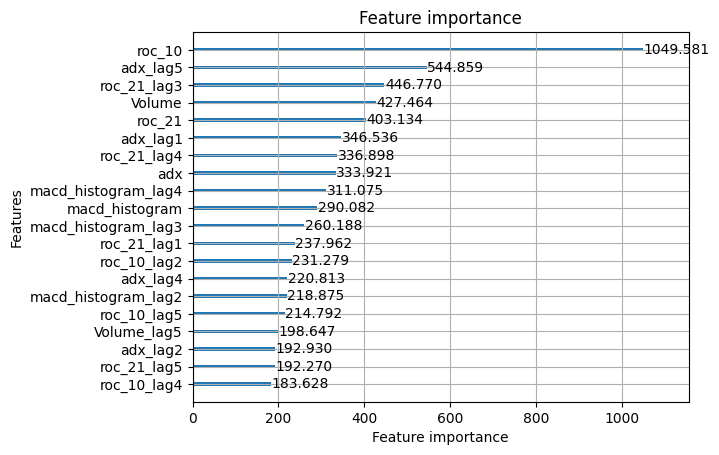

In [34]:
import matplotlib.pyplot as plt

# Feature importance
lgb.plot_importance(model, max_num_features=20, importance_type='gain')
plt.show()

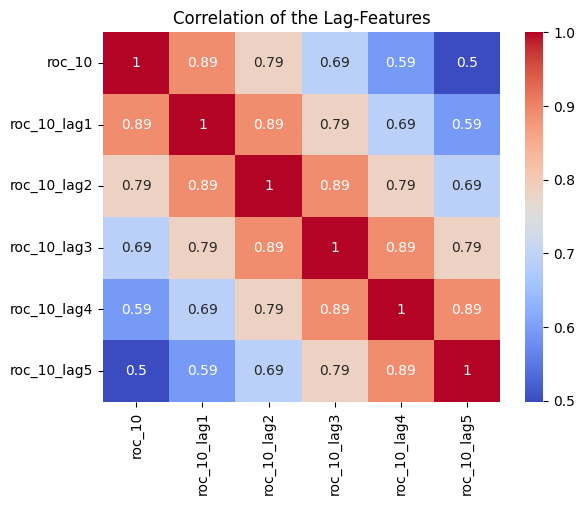

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation for a part of the features (for example ROC Lags)
lag_cols = [c for c in X.columns if 'roc_10' in c]
corr = X[lag_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation of the Lag-Features")
plt.show()

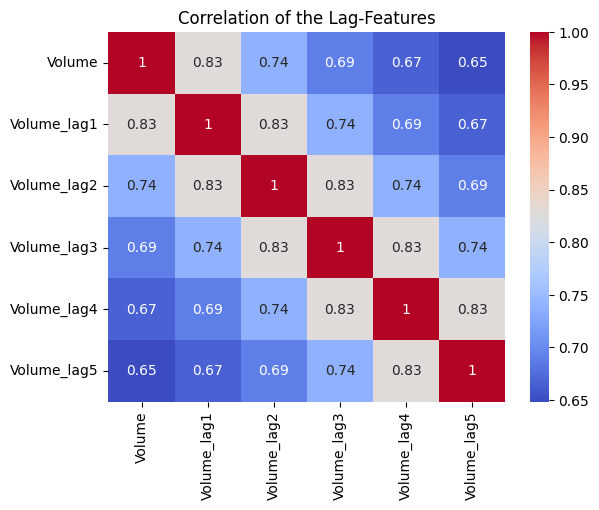

In [38]:
# Calculate correlation for a part of the features (for example ROC Lags)
lag_cols = [c for c in X.columns if 'Volume' in c]
corr = X[lag_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation of the Lag-Features")
plt.show()

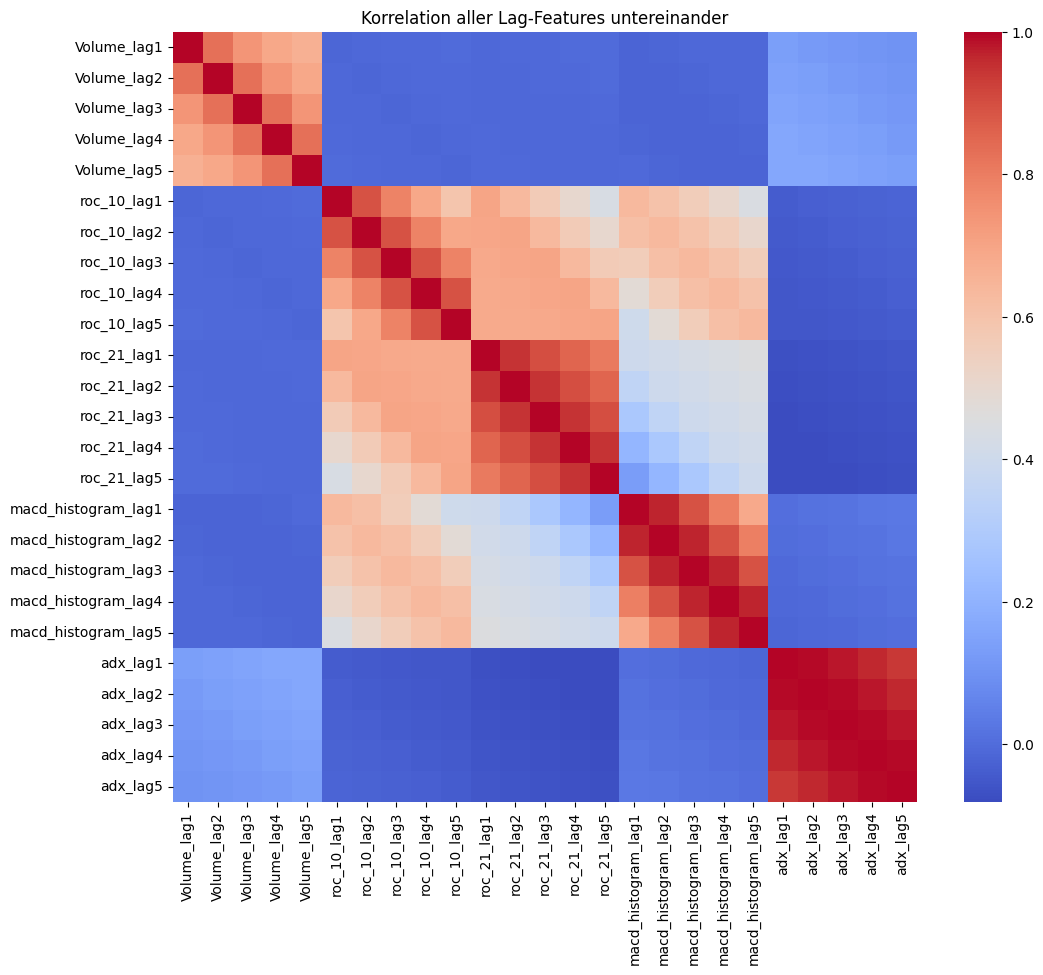

In [37]:
# 1. Alle Spalten finden, die "lag" im Namen haben
all_lag_cols = [c for c in X.columns if 'lag' in c]

# 2. Korrelation berechnen
lag_corr = X[all_lag_cols].corr()

# 3. Visualisierung (Heatmap)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(lag_corr, cmap='coolwarm', annot=False) # annot=False, sonst wird es zu voll
plt.title("Korrelation aller Lag-Features untereinander")
plt.show()